### 1: Import and install necessary libraries
In order to run these codes, please ensure that you install and import the neccessary libraries and the packages to see the Titanic surival prediction.

In [ ]:
%pip install ucimlrepo
%pip install -U scikit-learn
%pip install seaborn
%pip install matplotlib

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2: Download the Titanic CSVs files from the Kaggle ("Machine Learning from disaster):
All the Titanic datas to create the prediction model and the data proccessing will be taken from the Kaggle website from the Machine Learning from disaster.

In [55]:
# Loading the neccesary Titanic CSV dataset files found on the Kaggle Wesbite
print("Titanic Dataset csv:")
Titanic_Dataset = pd.read_csv('Titanic-Dataset.csv')
display(Titanic_Dataset)

print("------------------------------")

print("Titanic Training csv:")
Titanic_train = pd.read_csv("train.csv")
display(Titanic_train)

print("------------------------------")

print("Titanic Testing csv:")
Titanic_test = pd.read_csv("test.csv")
display(Titanic_test)

print("------------------------------")

print("Titanic Gender:")
Titanic_gender = pd.read_csv("gender_submission.csv")
display(Titanic_gender)

Titanic Dataset csv:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


------------------------------
Titanic Training csv:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


------------------------------
Titanic Testing csv:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


------------------------------
Titanic Gender:


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


### 3: Checking for null values: 
Before we begin to create any prediction for the Titanic surival, it is crucial that we check for any missing values for our columns. For instance, when we look at some of our various columns, it contained NaN. By doing a missing value checker, we double check to see if there are any columns that consists of any missing values.

In [56]:
print("Missing Values in Titanic Dataset:")
print(Titanic_Dataset.isnull().sum())

print("-------------------------------")

print("Missing Values in Titanic Training:")
print(Titanic_train.isnull().sum())


Missing Values in Titanic Dataset:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
-------------------------------
Missing Values in Titanic Training:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [57]:

print("Missing Values in Titanic Testing:")
print(Titanic_test.isnull().sum())

print("-------------------------------")

print("Missing values in the Gender:")
print(Titanic_gender.isnull().sum())

Missing Values in Titanic Testing:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64
-------------------------------
Missing values in the Gender:
PassengerId    0
Survived       0
dtype: int64


When we check in all our Titanic csvs files we can see that it contains many missing values from the training, testing and the dataset. However the gender does not contain any missing at all when we did the missign values checker. For example, in the Titanic dataset we can see that age, cabin, and the embarked contains missing values. Similiar to the Titanic dataset, the training also contains the missing values.

### 4: Titanic Surival distribution for the passenger on the board


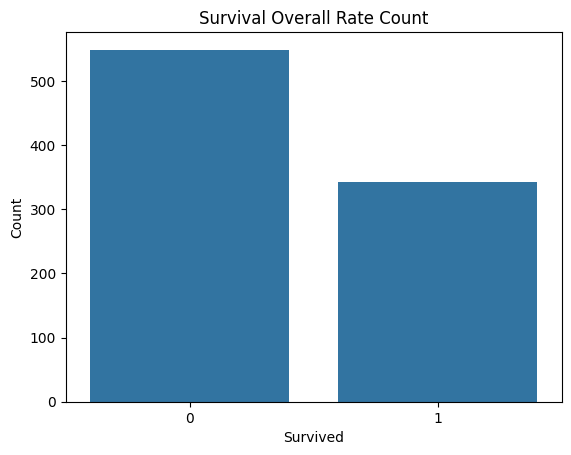

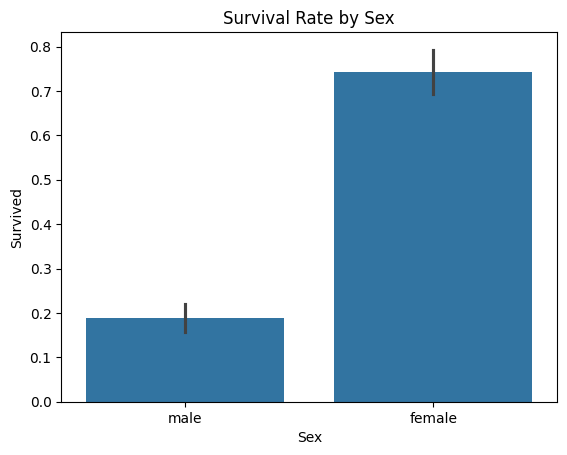

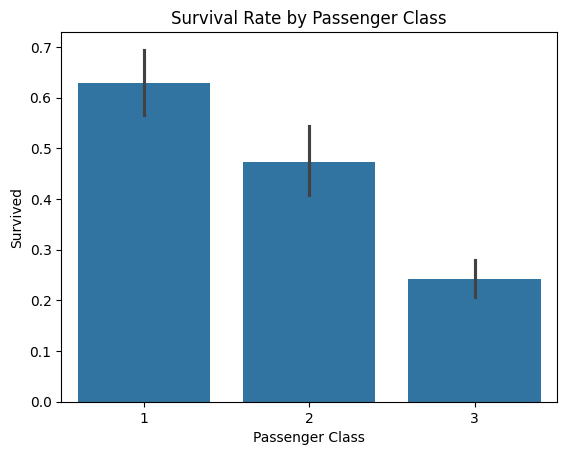

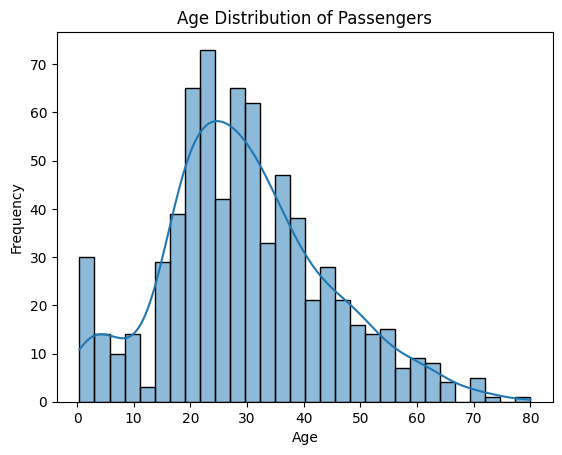

In [58]:
# Checking to see the surival rate distribution in the Titanic train dataset
# Observering the Titanic surival overall count (0: Did not surived, 1: Survived)
sns.countplot(x='Survived', data=Titanic_train)
plt.title('Survival Overall Rate Count')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

# Observing the surival rate distrubuted by the passenger's sex
sns.barplot(x='Sex', y='Survived', data=Titanic_train)
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survived')
plt.show()

# Observing the surival rate distrubuted by the passenger's class
sns.barplot(x='Pclass', y='Survived', data=Titanic_train)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survived')  
plt.show()

# Observing the surival rate distrubuted by the passenger's age
sns.histplot(Titanic_train['Age'].dropna(), bins=30, kde=True)
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Frequency') 
plt.show()

### 5: Combining data:
To ensure an accurate prediction and to to keep an organized data format to build these prediction we will be combining the Titanic CSV files. Because the train and the test have similiar features to each other, the test and the train csv will be combined. By doing this, we can accurately fixed our missing null values for some of our columns. 

In [59]:
# Combining the Titanic train and the test dataset 
Combined_dataset = pd.concat([Titanic_train, Titanic_test], sort = False)
print("Combined Dataset:")
display(Combined_dataset)

print("-------------------------------")
print("Missing Values in Combined Dataset:")
print(Combined_dataset.isnull().sum())

Combined Dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


-------------------------------
Missing Values in Combined Dataset:
PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64


Above showcases the combined dataset for the Titanic test and the train csv is now merged successfully. We also checked to see if the combined dataset contained any missing values.
For the combined dataset we can see that the columns surived, age, fare, cabin and the embarked all contains the missing values.

### 6: Handling Titanic missing values:

Currently we need to handle the following columns:Survived, Age, Fare,Cabin and Embarked.

In order to solved or find the missing values of these passengers, we firstly checked to see if any of these attributes have any similarit with each other. If we look at a passenger's age, we can mostly determined what class they are from. Since historically, the Titanic first class passenger will contained people who are older as they can afford the expensive 1st class tickets. Those who are in the 2nd or the 3rd class mostly contained people who are younger or moving their family to another place to work. By doing this we can create the best accurate prediction as possible for our dataset.


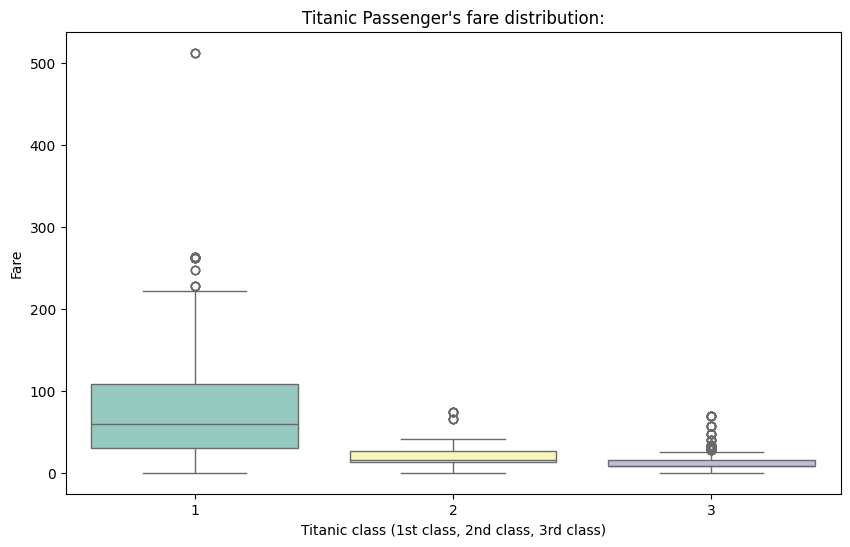

Median fare range per class on the Titanic:
Pclass
1    60.0000
2    15.0458
3     8.0500
Name: Fare, dtype: float64


In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
Combined_dataset = Combined_dataset.reset_index(drop=True)
sns.boxplot(x='Pclass',y='Fare',data=Combined_dataset,hue='Pclass',palette='Set3',legend=False)

plt.title("Titanic Passenger's fare distribution:")
plt.xlabel("Titanic class (1st class, 2nd class, 3rd class)")
plt.ylabel('Fare')
plt.show()

print("Median fare range per class on the Titanic:")
print(Combined_dataset.groupby('Pclass')['Fare'].median())

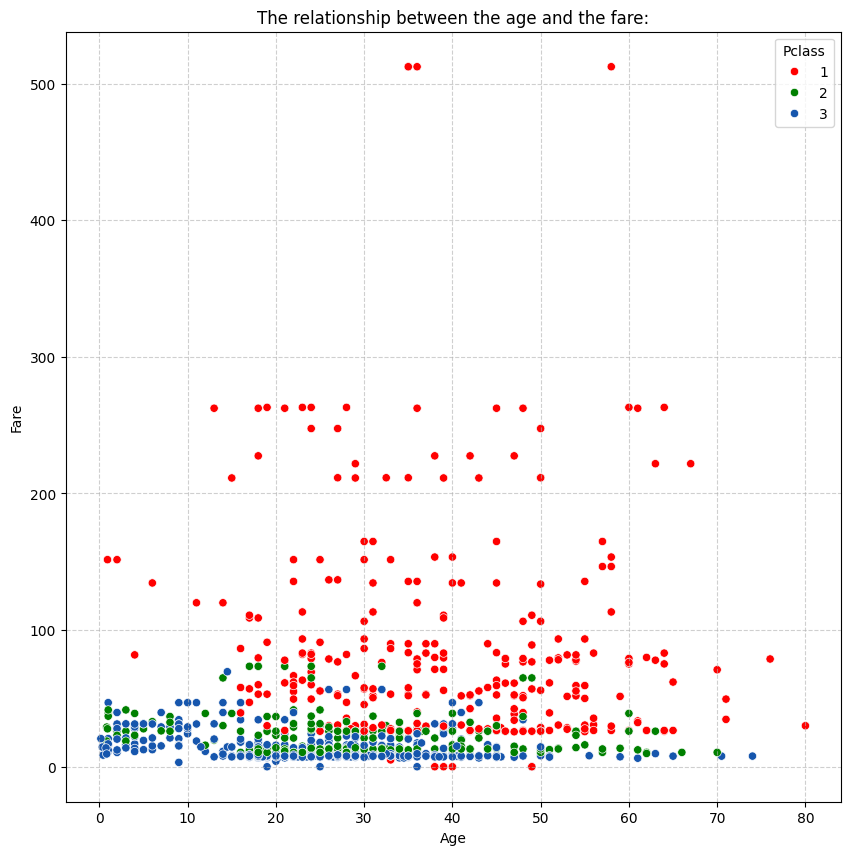

In [61]:
plt.figure(figsize=(10,10))
custom_colors = ['#FF0000', '#008000', '#1656AD'] 
Combined_dataset = Combined_dataset.reset_index(drop=True)
sns.scatterplot(x='Age',y='Fare',hue='Pclass',data=Combined_dataset,palette=custom_colors)
plt.title("The relationship between the age and the fare:")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.grid(True,linestyle='--',alpha=.6)
plt.show()

The median fare for the 3rd class passengers who embarked from S is:  8.05


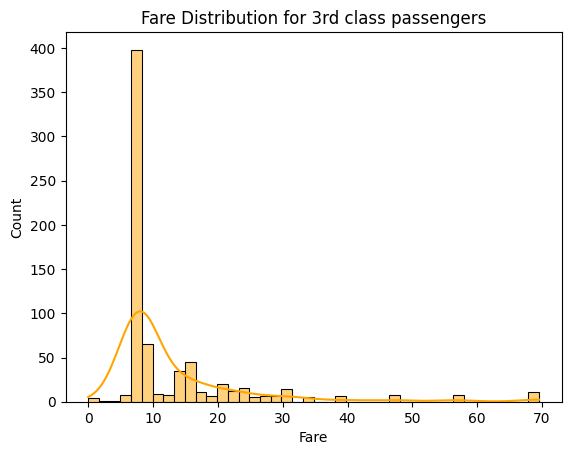

In [62]:
# Showcasing the missing values for the Titanic Dataset fare column
Titanic_median_fare = Combined_dataset[(Combined_dataset['Pclass'] == 3) & (Combined_dataset['Embarked'] == 'S')]['Fare'].median()

# Combining the median fare for our 3rd class passenger who embarked from the port of Southampton to the missing values in the fare column of our combined dataset
Combined_dataset["Fare"] = Combined_dataset["Fare"].fillna(Titanic_median_fare)
print("The median fare for the 3rd class passengers who embarked from S is: ", Titanic_median_fare)

#Showcasing our distrution of our passenger's fare who are in the 3rd class on the Titanic
sns.histplot(Combined_dataset[Combined_dataset["Pclass"]==3]["Fare"], kde=True, color='orange')
plt.title("Fare Distribution for 3rd class passengers")
plt.show()


When we look at the both of the graphs, we can see that each of the Titanic class median for all the passengers that aboard the Titanic. For example, we can see that in the Titanic first class, the average age median was 37.0 which means that the older passengers are mostly the one who can afford to buy tickets for the first class. In the second class, we see that the median was a 29.0 and for the third class we can see that the average class is about 24.0. Which means by looking at this, we can see that age plays a factor in the classes the passengers are in.

Firstly, we begin to deal with the missing values for our fare and the embarked columns for our combined Titanic dataset. We displayed the fare and the embarked column to see which passengers they belong to. And possibly see what classes they belong to.

In [63]:
display(Combined_dataset[Combined_dataset['Fare'].isnull()])
display(Combined_dataset.iloc[1043])

print("--------------------------------")
display(Combined_dataset[Combined_dataset['Embarked'].isnull()])
display(Combined_dataset.iloc[60])
display(Combined_dataset.iloc[828])

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


PassengerId                  1044
Survived                      NaN
Pclass                          3
Name           Storey, Mr. Thomas
Sex                          male
Age                          60.5
SibSp                           0
Parch                           0
Ticket                       3701
Fare                         8.05
Cabin                         NaN
Embarked                        S
Name: 1043, dtype: object

--------------------------------


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1.0,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1.0,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


PassengerId                       61
Survived                         0.0
Pclass                             3
Name           Sirayanian, Mr. Orsen
Sex                             male
Age                             22.0
SibSp                              0
Parch                              0
Ticket                          2669
Fare                          7.2292
Cabin                            NaN
Embarked                           C
Name: 60, dtype: object

PassengerId                             829
Survived                                1.0
Pclass                                    3
Name           McCormack, Mr. Thomas Joseph
Sex                                    male
Age                                     NaN
SibSp                                     0
Parch                                     0
Ticket                               367228
Fare                                   7.75
Cabin                                   NaN
Embarked                                  Q
Name: 828, dtype: object

In [64]:
# Looking into the Titanic age and the class of the passengers median
Titanic_Pclass_Age = Combined_dataset.groupby('Pclass')['Age'].median()
print("Median Age by Passenger Class:")
print(Titanic_Pclass_Age)

def Pclass_Age(x):
    if pd.isnull(x['Age']):
        return Titanic_Pclass_Age[x['Pclass']]
    else:
        return x['Age']
Combined_dataset['Age'] = Combined_dataset.apply(Pclass_Age, axis=1)

print("--------------------------------")

# Looking into the Titanic age and the class of the passengers mean
print("Titanic class and age mean:")
print(Combined_dataset.groupby('Pclass')['Age'].mean())

Median Age by Passenger Class:
Pclass
1    39.0
2    29.0
3    24.0
Name: Age, dtype: float64
--------------------------------
Titanic class and age mean:
Pclass
1    39.140619
2    29.477437
3    24.576869
Name: Age, dtype: float64


In [65]:
# Handling the missing values for the embark column in the Titanic combined dataset
Combined_dataset['Embarked'] = Combined_dataset['Embarked'].fillna(Combined_dataset['Embarked'].mode()[0])
print("Checking for the missing values in the embark column:")
print(Combined_dataset['Embarked'].isnull().sum())

print("--------------------------------")
print(Combined_dataset.isnull().sum())

Checking for the missing values in the embark column:
0
--------------------------------
PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1014
Embarked          0
dtype: int64


In [66]:
# Handling the missing values for the fare column in the Titanic combined dataset
Combined_dataset = Combined_dataset.reset_index(drop=True)
Combined_dataset['Fare'] = Combined_dataset['Fare'].fillna(Combined_dataset['Fare'].median())
print("Checking for the missing values in the fare column:")    
print(Combined_dataset['Fare'].isnull().sum())

print("--------------------------------")
print(Combined_dataset.isnull().sum())

Checking for the missing values in the fare column:
0
--------------------------------
PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1014
Embarked          0
dtype: int64


In [67]:
# 1. Extract the Titanic Deck 
Combined_dataset['Deck'] = Combined_dataset['Cabin'].str[0]

# Filled in the missing decks with the unknown value for the passengers

Combined_dataset['Deck'] = Combined_dataset['Deck'].fillna('Unknown')

# Drop the cabin column since we have extracted the Titanic decks
Combined_dataset = Combined_dataset.drop('Cabin', axis=1)
print(Combined_dataset[['Deck', 'Survived']].head())

      Deck  Survived
0  Unknown       0.0
1        C       1.0
2  Unknown       1.0
3        C       1.0
4  Unknown       0.0


In [68]:
# Checking to ensure that the Cabin column has been dropped
display(Combined_dataset.isnull().sum())

PassengerId      0
Survived       418
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
Deck             0
dtype: int64

### 7: Extracting additional information
Now our values of the Titanic dataset have been mostly filled out. We begin to extract additional information for our Titanc dataset. A passenger's age, family size, fare groups and their sex plays a huge role that allows us to build a more accurate prediction model.

Firstly, we will extract the Titanic passengers titles because it can tell us a lot about the passengers that are on board. Passengers who are mostly in the first class might contain information regarding their status or their age. Which can correlates to the fare costs.

In [69]:
"""
Titanic titles:
- Mr.
- Mrs.
- Miss
- Countess
- Sir
- Lady
- Captain
- Col
- Don
- Dr
- Major
- Rev
- Jonkheer (Dutch honorific for a nobleman)
- Dona (Spanish honorific title for a lady)
"""

# Extracting and dealing with the Titanic passenger's titles 
Combined_dataset['Title'] = Combined_dataset['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

Combined_dataset["Title"] = Combined_dataset["Title"].astype("category").cat.codes

# Titanic's passengers titles
Combined_dataset['Title'] = Combined_dataset['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Other')
Combined_dataset['Title'] = Combined_dataset['Title'].replace('Mlle', 'Miss')
Combined_dataset['Title'] = Combined_dataset['Title'].replace('Ms', 'Miss')
Combined_dataset['Title'] = Combined_dataset['Title'].replace('Mme', 'Mrs')

In [70]:
print("Titanic's passengers titles value:")
display(Combined_dataset['Title'].value_counts())


Titanic's passengers titles value:


Title
13    757
10    260
14    197
9      61
16      8
5       8
1       4
15      2
8       2
11      2
3       1
12      1
7       1
17      1
0       1
2       1
6       1
4       1
Name: count, dtype: int64

Secondly, we consider the family size of all the Titanic passengers that are on board as it can help us create a more of an accurate prediction. During the disaster after the iceberg hits the Titanic, the smaller family size are mostly surived more than a bigger family size. It is noted that there wasn't enough lifeboats and the life vest for all the passengers to used so the larger family are less likely to survied.

In [71]:
"""
Extracting the Titanic's family size
Sibsp = Number of the siblings or spouses on board the Titanic
Parch stands for the numer of the parents and the children on board the TitanicWe combined the siblings/spouses and the parents/children in order to get a more accurate 
prediction to build our model later
"""
Combined_dataset['FamilySize'] = Combined_dataset['SibSp'] + Combined_dataset['Parch'] + 1
print("Titanic's passengers family size value counts:")
display(Combined_dataset['FamilySize'].value_counts())

Titanic's passengers family size value counts:


FamilySize
1     790
2     235
3     159
4      43
6      25
5      22
7      16
11     11
8       8
Name: count, dtype: int64

Thirdly, we consider the age group of all our passengers on the Titanic. It is noted that women and the children are consider first to get a life jacket and to board on the life boat during this disaster. Since they are more prioritize in comparison to the men, they are mostly surived.

In [72]:
"""
Extracting the Titanic's age groups
"""
Combined_dataset['AgeGroup'] = pd.cut(
    Combined_dataset['Age'], 
    bins=[0, 12, 18, 35, 60, np.inf], 
    labels=['Child', 'Teenager', 'Adult', 'Middle-aged', 'Senior']
)

age_map = {
    'Child': 0,
    'Teenager': 1,
    'Adult': 2,
    'Middle-aged': 3,
    'Senior': 4
}

Combined_dataset['AgeGroup'] = Combined_dataset['AgeGroup'].map(age_map)

In [73]:
display(Combined_dataset["AgeGroup"].value_counts())

AgeGroup
2    755
3    328
1     99
0     94
4     33
Name: count, dtype: int64

Fourthly, we also takes the fare group to the consideration as the fare can tell us about what class the passengers are located in. It is noted that the first class passengers have more priviliged and more accessible amenities in comparison to those who are in the second or the third class. The first class consist of rich or well-known people on the ship. While the second class consist of the middle class people. And the third class people often consist of the workers that work on the Titanic and the immigrants who are onboard in hope to find new opportunity. It is important to remember that the third class were further away from all the decks and were almost the last one to be informed about the disasters.

In [74]:
""""
Extracting the fare groups of the Titanic passengers to create an accurate 
prediction in order to build our model.
"""
Combined_dataset['FareGroup'] = pd.qcut(
    Combined_dataset['Fare'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High'],
    duplicates='drop'
)
fare_map = {
    'Low': 0,
    'Medium': 1,
    'High': 2,
    'Very High': 3
}
Combined_dataset['FareGroup'] = Combined_dataset['FareGroup'].map(fare_map) 

In [75]:
display(Combined_dataset["FareGroup"].value_counts())

FareGroup
0    337
2    328
3    323
1    321
Name: count, dtype: int64

Fifth, the passenger's sex plays a huge role when it comes to the Titanic surival rate. The Titanic policy when it comes to who get priority on the life boat was women and the children first. So, we extract the sex of the passengers in order to get the value counts.

In [76]:
"""
Extracting the Titanic's sex of the passengers in order to create an accurate
prediction to build our model.
For male passengers will be represented as 0
For female passengers will be represented as 1
"""
Combined_dataset['Sex'] = Combined_dataset['Sex'].map({'male': 0, 'female': 1})
Combined_dataset = pd.get_dummies(
    Combined_dataset, 
    columns=['Embarked', 'Deck']
)

print("Titanic's passengers sex group value counts:")
display(Combined_dataset['Sex'].value_counts())

Titanic's passengers sex group value counts:


Sex
0    843
1    466
Name: count, dtype: int64

In [77]:
"""
Displaying the current survived rate of the Titanic passenger's titles,
family size, age group, fare group and their sex.
"""

# Checking to see if the title exist in the combine dataset
if 'Title' not in Combined_dataset.columns:
    Combined_dataset['Title'] = Combined_dataset['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    Combined_dataset['Title'] = Combined_dataset['Title'].replace(
        ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'],
        'Other'
    )
    Combined_dataset['Title'] = Combined_dataset['Title'].replace('Mlle', 'Miss')
    Combined_dataset['Title'] = Combined_dataset['Title'].replace('Ms', 'Miss')
    Combined_dataset['Title'] = Combined_dataset['Title'].replace('Mme', 'Mrs')

# Function to display survival rate
def display_survival_rate():
    train_only = Combined_dataset[Combined_dataset['Survived'].notnull()]
    
    features = ['Title', 'FamilySize', 'AgeGroup', 'FareGroup', 'Sex']
    
    for feature in features:
        if feature not in train_only.columns:
            print(f"Skipping missing feature: {feature}")
            continue
            
        survival_rate = train_only.groupby(feature)['Survived'].mean()
        
        print(f"\nSurvival Rate by {feature}:")
        display(survival_rate)
        print("-----------------------------")

display_survival_rate()


Survival Rate by Title:


Title
0     0.000000
1     0.500000
2     1.000000
3     0.000000
5     0.428571
6     0.000000
7     1.000000
8     0.500000
9     0.575000
10    0.697802
11    1.000000
12    1.000000
13    0.156673
14    0.792000
15    1.000000
16    0.000000
17    1.000000
Name: Survived, dtype: float64

-----------------------------

Survival Rate by FamilySize:


FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

-----------------------------

Survival Rate by AgeGroup:


...

-----------------------------

Survival Rate by FareGroup:


FareGroup
0    0.197309
1    0.303571
2    0.441048
3    0.600000
Name: Survived, dtype: float64

-----------------------------

Survival Rate by Sex:


Sex
0    0.188908
1    0.742038
Name: Survived, dtype: float64

-----------------------------


### 8: Handling unique values:
While our Titanic dataset contains many unique values that could give us information about the passengers. There are some unique features or the information that wouldn't be able to help us with the prediction the surival rate outcome if we are on board the Titanic. Columns such as the Titanic passengers IDs and the name won't be much of a help when it comes to the prediction model.

In [78]:
# Displaying the uniques value count for the Titanc data
def display_unique_value_counts():
    train_only = Combined_dataset[Combined_dataset['Survived'].notnull()]
    
    features = ['Pclass', 'Sex', 'FamilySize', 'Title', 'Embarked', 'Deck']
    
    for feature in features:
        if feature not in train_only.columns:
            print(f"Skipping missing feature: {feature}")
            continue
        
        print(f"\n=== Unique Value Counts for {feature} ===")
        display(train_only[feature].value_counts())
        print("-----------------------------")
    
    # Handle numeric separately
    print("\n=== Age Distribution===")
    display(pd.cut(train_only['Age'], bins=10).value_counts())
    
    print("\n=== Fare Distribution===")
    display(pd.cut(train_only['Fare'], bins=10).value_counts())

display_unique_value_counts()


=== Unique Value Counts for Pclass ===


Pclass
3    491
1    216
2    184
Name: count, dtype: int64

-----------------------------

=== Unique Value Counts for Sex ===


Sex
0    577
1    314
Name: count, dtype: int64

-----------------------------

=== Unique Value Counts for FamilySize ===


...

Title
13    517
10    182
14    125
9      40
5       7
16      6
8       2
11      2
1       2
3       1
12      1
15      1
7       1
17      1
0       1
2       1
6       1
Name: count, dtype: int64

-----------------------------
Skipping missing feature: Embarked
Skipping missing feature: Deck

=== Age Distribution===


Age
(16.336, 24.294]    313
(24.294, 32.252]    180
(32.252, 40.21]     148
(40.21, 48.168]      70
(0.34, 8.378]        54
(8.378, 16.336]      46
(48.168, 56.126]     45
(56.126, 64.084]     24
(64.084, 72.042]      9
(72.042, 80.0]        2
Name: count, dtype: int64


=== Fare Distribution===


Fare
(-0.512, 51.233]      732
(51.233, 102.466]     106
(102.466, 153.699]     31
(204.932, 256.165]     11
(256.165, 307.398]      6
(461.096, 512.329]      3
(153.699, 204.932]      2
(307.398, 358.63]       0
(358.63, 409.863]       0
(409.863, 461.096]      0
Name: count, dtype: int64

Above we are showcases the the unique values in the Titanic combined dataset. As mentioned before the prediction model needs neccessary information in order to create an accurate prediction. First, we split the Titanic combined dataset back into our 2 previous files which are the train and the test. This process is known as the feature engineering which is basically to improve our machine learning model to have a more accurate results. We also ensure that there are no missing values in either of of our test and the train files.

In [ ]:
# # Seperate the combined dataset into train and test 
# train_df = Combined_dataset[Combined_dataset['Survived'].notnull()]
# test_df = Combined_dataset[Combined_dataset['Survived'].isnull()]

# # Creating a selection of which features that would be used to train our prediction model.
# # Unique attributes such as Name, ticket, passengerId will not be considered as it is not useful
# features = ['Pclass', 'Title', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 
#             'Embarked_C', 'Embarked_Q', 'Embarked_S', 
#             'Deck_A', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G']

# X = train_df[features]
# y = train_df['Survived']
# X_test = test_df[features]

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, classification_report

# # Split our models for the training data in order to evualate the performance of the models
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# #  Building our random forrest model to preduct the survival rate of the passengers
# model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
# model.fit(X_train, y_train)

# # Checking the accuracy of the model
# val_predictions = model.predict(X_val)
# print(f"Validation Accuracy: {accuracy_score(y_val, val_predictions):.2f}")
# print("\nClassification Report:\n", classification_report(y_val, val_predictions))

In [ ]:
# from sklearn.preprocessing import LabelEncoder
# train_df_model = train_df.copy()

# # Dropping any columns that are not neccessary:
# drop_columns = ["Name", "Ticket", "Cabin", "PassengerId"]
# train_df_model = train_df_model.drop(columns=drop_columns, errors = 'ignore')

# # Begin to encode the catergorical varaibles
# label_encoders = {}
# Catergorical_features = ["Sex","Embarked","Title","AgeGroup","FareGroup","Deck"]
# for col in Catergorical_features:
#     if col in train_df_model.columns:
#         le = LabelEncoder()
#         train_df_model[col] = le.fit_transform(train_df_model[col])
#         label_encoders[col] = le
# train_df_model.head()

In [ ]:
# X = train_df_model.drop("Survived", axis = 1)
# y = train_df_model["Survived"]

In [79]:
# Handle missing values
Titanic_train['Age'] = Titanic_train['Age'].fillna(Titanic_train['Age'].median())
Titanic_train['Embarked'] = Titanic_train['Embarked'].fillna(Titanic_train['Embarked'].mode()[0])
Titanic_train['Fare'] = Titanic_train['Fare'].fillna(Titanic_train['Fare'].median())

# Convert categorical variables to numeric (Encoding)
Titanic_train['Sex'] = Titanic_train['Sex'].map({'male': 0, 'female': 1})
Titanic_train = pd.get_dummies(Titanic_train, columns=['Embarked'])

# Drop columns that won't help the model (identifiers and high-cardinality strings)
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
train_df_model = Titanic_train.drop(columns=drop_cols)

In [ ]:
display(Titanic_train.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked_C       0
Embarked_Q       0
Embarked_S       0
dtype: int64

In [81]:
from sklearn.model_selection import train_test_split
X = train_df_model.drop("Survived", axis = 1)
y = train_df_model["Survived"]
x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Training the random forest model
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(x_train, y_train)

# Creating a prediction on the validation set 
y_pred = model.predict(x_val)

print(f"Validation Accuracy: {accuracy_score(y_val, y_pred):.2f}")
print(classification_report(y_val, y_pred))

Validation Accuracy: 0.82
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.84      0.69      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179

